# Batch Gradient Descent

This notebook explores **batch gradient descent**, a fundamental optimization algorithm used to minimize loss functions in machine learning. We'll cover the mathematical foundations, implementation details, and practical applications.

## Important Note on Mathematical Notation

Throughout this notebook, whenever we use a mathematical concept or formula (such as derivatives, gradients, or optimization updates), we first present the **general foundational principle** before applying it to our specific problem. This approach ensures clarity by:

1. Introducing the general concept and formula
2. Explaining what each component means
3. Showing how we apply it to gradient descent

This makes it easier to understand not just *how* gradient descent works, but *why* it works and where it comes from.

## 1. Introduction to Gradient Descent

### 1.1 The Optimization Problem

In machine learning, we want to find parameters $\theta$ that minimize a loss function $J(\theta)$:

$$\min_{\theta} J(\theta)$$

where:
- $\theta$: Parameters of our model (weights, biases, etc.) that we want to learn
- $J(\theta)$: The loss function (measures how bad our predictions are)
- We want to find the $\theta$ values that make $J(\theta)$ as small as possible

#### Different Forms of Representing Data

Before we write the loss function, let's clarify the notation for data by showing three equivalent representations:

**Form 1: Single Sample (Equation/Scalar Form)**

For a single sample $i$ (the $i$-th data point):
- $x_i = [\text{feature}_1, \text{feature}_2, \ldots, \text{feature}_p]$ (feature vector for sample $i$)
- $y_i$ (target value for sample $i$)
- $\theta = [\theta_0, \theta_1, \ldots, \theta_p]$ (parameter vector)
- Prediction: $\hat{y}_i = \theta^T x_i = \theta_0 + \theta_1 x_{i,1} + \cdots + \theta_p x_{i,p}$

**Form 2: Array/Vector Form (Multiple Samples)**

We can write the loss over multiple samples as a sum:

$$J(\theta) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = \frac{1}{n}\sum_{i=1}^{n}(y_i - \theta^T x_i)^2$$

where:
- $n$: Total number of samples
- $i$: Index running from 1 to $n$ (each sample)
- $(y_i - \hat{y}_i)^2$: Squared error for sample $i$

**Form 3: Matrix Form (Compact/Computational Form)**

We can write the same loss compactly using matrices:

$$J(\theta) = \frac{1}{n}\|y - X\theta\|_2^2 = \frac{1}{n}(y - X\theta)^T(y - X\theta)$$

where:
- $X \in \mathbb{R}^{n \times p}$: Feature matrix (rows are samples, columns are features)
- $y \in \mathbb{R}^{n}$: Target vector (column vector of all targets)
- $\theta \in \mathbb{R}^{p}$: Parameter vector
- $\|·\|_2$: Euclidean norm (L2 norm)

$$X = \begin{bmatrix} 1 & x_{1,1} & x_{1,2} & \cdots & x_{1,p} \\ 1 & x_{2,1} & x_{2,2} & \cdots & x_{2,p} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n,1} & x_{n,2} & \cdots & x_{n,p} \end{bmatrix}, \quad y = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}, \quad \theta = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_p \end{bmatrix}$$

**Concrete Example: House Price Prediction**

Suppose we have 3 houses with 2 features (size, age):

| Sample | Size ($x_1$) | Age ($x_2$) | Price ($y$) |
|--------|------------|---------|----------|
| House 1 | 2000 | 5 | 300k |
| House 2 | 1500 | 10 | 250k |
| House 3 | 3000 | 2 | 400k |

**Scalar form** (sample 1):
- $x_1 = [1, 2000, 5]$ (feature vector: intercept term + features)
- $y_1 = 300$

**Vector form** (all samples):
$$\sum_{i=1}^{3}(y_i - \theta^T x_i)^2 = (y_1 - \theta^T x_1)^2 + (y_2 - \theta^T x_2)^2 + (y_3 - \theta^T x_3)^2$$

**Matrix form** (all data at once):
$$X = \begin{bmatrix} 1 & 2000 & 5 \\ 1 & 1500 & 10 \\ 1 & 3000 & 2 \end{bmatrix}, \quad y = \begin{bmatrix} 300 \\ 250 \\ 400 \end{bmatrix}, \quad X\theta = \begin{bmatrix} \theta_0 + 2000\theta_1 + 5\theta_2 \\ \theta_0 + 1500\theta_1 + 10\theta_2 \\ \theta_0 + 3000\theta_1 + 2\theta_2 \end{bmatrix}$$

**Why three forms?**
- **Scalar form**: Intuitive, shows what each variable means
- **Vector form**: Shows the mathematical structure, easy for derivations
- **Matrix form**: Efficient for computation, used in implementations

For example, in linear regression, we minimize the mean squared error (MSE):

$$J(\theta) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \theta^T x_i)^2 = \frac{1}{n}\|y - X\theta\|_2^2$$

### 1.2 Key Insight: The Gradient Points Uphill

The **gradient** of a function at a point tells us the direction of steepest increase. Think of it like standing on a hillside:
- The gradient points UP the steepest slope
- To go DOWN (minimize), we move in the OPPOSITE direction of the gradient
- The magnitude (size) of the gradient tells us how steep the hill is

This is the core idea behind gradient descent: **take small steps in the direction opposite to the gradient to reach the minimum**.

## 2. Mathematical Foundations

### 2.1 Derivatives and Gradients

#### The Derivative (Single Variable)

We know that the **derivative** of a function $f(x)$ at a point $x$ measures how much the function changes when we change $x$ slightly:

$$\frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Intuitively:
- $\frac{df}{dx} > 0$: Function is increasing (going uphill)
- $\frac{df}{dx} < 0$: Function is decreasing (going downhill)
- $\frac{df}{dx} = 0$: Function has a critical point (peak, valley, or saddle)
- $|\frac{df}{dx}|$ large: Function is steep
- $|\frac{df}{dx}|$ small: Function is flat

#### The Gradient (Multiple Variables)

For a function $J(\theta)$ where $\theta = [\theta_1, \theta_2, \ldots, \theta_p]^T$ has multiple parameters, the **gradient** is a vector of partial derivatives:

$$\nabla J(\theta) = \begin{bmatrix} \frac{\partial J}{\partial \theta_1} \\ \frac{\partial J}{\partial \theta_2} \\ \vdots \\ \frac{\partial J}{\partial \theta_p} \end{bmatrix}$$

where:
- $\nabla$ ("nabla") is the gradient operator
- $\frac{\partial J}{\partial \theta_j}$: Partial derivative of $J$ with respect to parameter $\theta_j$ (holding other parameters fixed)
- The gradient points in the direction of steepest increase
- The magnitude $\|\nabla J(\theta)\|$ tells us how steep the surface is at that point

### 2.2 Taylor Expansion and Gradient Descent

#### Taylor Expansion (Linear Approximation)

We know that **Taylor expansion** approximates a smooth function using its derivatives:

$$f(x + \Delta x) \approx f(x) + \frac{df}{dx}\Delta x + O((\Delta x)^2)$$

For a function of multiple variables:

$$J(\theta + \Delta \theta) \approx J(\theta) + (\nabla J(\theta))^T \Delta \theta$$

where:
- $J(\theta)$: Current loss value
- $(\nabla J(\theta))^T \Delta \theta$: Linear approximation of how the loss changes with parameter update $\Delta \theta$
- The dot product $(\nabla J(\theta))^T \Delta \theta$ is maximized when $\Delta \theta$ points in the direction of $\nabla J(\theta)$

#### Applying to Gradient Descent

To minimize $J(\theta)$, we want $J(\theta + \Delta \theta) < J(\theta)$, which means:

$$(\nabla J(\theta))^T \Delta \theta < 0$$

This is satisfied when we update parameters in the direction **opposite** to the gradient:

$$\Delta \theta = -\alpha \nabla J(\theta)$$

where:
- $\alpha > 0$: Learning rate (controls step size)
- The negative sign ensures we move downhill
- Larger $\alpha$ = bigger steps, Smaller $\alpha$ = smaller, more careful steps

## 3. Batch Gradient Descent Algorithm

### 3.1 Algorithm Overview

**Batch Gradient Descent (BGD)** uses the entire dataset to compute the gradient at each iteration:

**Algorithm:**

1. Initialize parameters: $\theta^{(0)}$ (randomly or with smart initialization)
2. For each iteration $t = 0, 1, 2, \ldots$:
   - Compute loss on ALL samples: $J(\theta^{(t)}) = \frac{1}{n}\sum_{i=1}^{n} \ell(y_i, \hat{y}_i^{(t)})$
   - Compute gradient on ALL samples: $\nabla J(\theta^{(t)}) = \frac{1}{n}\sum_{i=1}^{n} \nabla \ell(y_i, \hat{y}_i^{(t)})$
   - Update parameters: $\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla J(\theta^{(t)})$
3. Stop when convergence criterion is met (e.g., gradient is near zero, loss stops decreasing)

where:
- $\ell(y_i, \hat{y}_i)$: Loss for sample $i$
- $\frac{1}{n}$: Average over all $n$ samples (batch = entire dataset)
- $\alpha$: Learning rate (hyperparameter we choose)

### 3.2 Update Rule

The core update at each iteration is:

$$\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla J(\theta^{(t)})$$

Breaking this down:
- $\theta^{(t)}$: Parameters from previous iteration $t$
- $\nabla J(\theta^{(t)})$: Gradient (direction of steepest increase)
- $-\alpha \nabla J(\theta^{(t)})$: Negative gradient scaled by learning rate (direction and size of step)
- $\theta^{(t+1)}$: Updated parameters after taking the step

This can be rewritten as:

$$\theta^{(t+1)} \leftarrow \theta^{(t)} - \alpha \frac{1}{n}\sum_{i=1}^{n} \nabla \ell(y_i, \theta^{(t)T} x_i)$$

where the gradient is averaged over the batch (entire dataset).

### 3.3 Why "Batch"?

The name "batch" comes from the fact that we use the **entire batch** (all samples) to compute each gradient:

- **Batch Gradient Descent**: Use all $n$ samples to compute gradient → stable, accurate estimates, but slow per iteration
- **Stochastic Gradient Descent (SGD)**: Use 1 sample at a time → fast iterations, but noisy gradient estimates
- **Mini-batch Gradient Descent**: Use $k$ samples ($1 < k < n$) → balance between stability and speed

### 3.4 Convergence Properties

**Advantages of Batch Gradient Descent:**
- **Stable**: Uses all data, so gradient estimate is accurate and low-variance
- **Smooth convergence**: Loss curve is smooth (no noise)
- **Guaranteed convergence**: For convex functions, guaranteed to reach global minimum
- **Parallelizable**: Can compute gradients for all samples in parallel

**Disadvantages:**
- **Slow per iteration**: Must process entire dataset for each gradient computation
- **Memory intensive**: Need to store data and intermediate computations for all samples
- **Global minimum only for convex functions**: For non-convex functions (like neural networks), may get stuck in local minima

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set random seed for reproducibility
np.random.seed(42)

## 4. Implementation: Linear Regression with Batch Gradient Descent

### 4.1 Gradient for Mean Squared Error (MSE)

For linear regression with loss function:

$$J(\theta) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - \theta^T x_i)^2$$

The gradient with respect to $\theta$ is:

$$\nabla J(\theta) = -\frac{1}{n}\sum_{i=1}^{n}(y_i - \theta^T x_i) x_i = -\frac{1}{n} X^T(y - X\theta)$$

where:
- $X$: $n \times p$ design matrix (rows are samples)
- $y$: $n \times 1$ target vector
- $(y - X\theta)$: $n \times 1$ residuals
- $X^T(y - X\theta)$: Aggregates gradient contribution from all samples

In [2]:
# Generate synthetic linear regression data
n_samples = 100
X = np.random.randn(n_samples, 1)
true_slope = 2.5
true_intercept = 1.0
noise = np.random.randn(n_samples) * 0.5

y = true_intercept + true_slope * X.flatten() + noise

# Add bias term (intercept) to X
X_with_bias = np.hstack([np.ones((n_samples, 1)), X])

print(f"Data shape: X={X_with_bias.shape}, y={y.shape}")
print(f"True parameters: intercept={true_intercept}, slope={true_slope}")

Data shape: X=(100, 2), y=(100,)
True parameters: intercept=1.0, slope=2.5


In [3]:
def mse_loss(y_true, y_pred):
    """Compute mean squared error loss."""
    return np.mean((y_true - y_pred) ** 2) / 2

def gradient_mse(X, y, theta):
    """Compute gradient of MSE loss.
    
    Args:
        X: n x p design matrix
        y: n x 1 target vector
        theta: p x 1 parameter vector
    
    Returns:
        grad: p x 1 gradient vector
    """
    n = X.shape[0]
    predictions = X @ theta
    residuals = predictions - y
    # Gradient = -1/n * X^T * residuals
    grad = (1 / n) * (X.T @ residuals)
    return grad

def batch_gradient_descent(X, y, learning_rate=0.01, n_iterations=100, verbose=False):
    """Batch Gradient Descent optimization.
    
    Args:
        X: n x p design matrix
        y: n x 1 target vector
        learning_rate: Step size alpha
        n_iterations: Number of iterations
        verbose: Print progress
    
    Returns:
        theta: Optimized parameters
        loss_history: List of loss values at each iteration
        theta_history: List of parameter values at each iteration
    """
    n_features = X.shape[1]
    # Initialize parameters to zero
    theta = np.zeros((n_features, 1))
    
    loss_history = []
    theta_history = [theta.copy()]
    
    for iteration in range(n_iterations):
        # Compute predictions and loss
        y_pred = X @ theta
        loss = mse_loss(y, y_pred)
        loss_history.append(loss)
        
        # Compute gradient on entire batch (all n samples)
        grad = gradient_mse(X, y, theta)
        
        # Update parameters: theta = theta - learning_rate * gradient
        theta = theta - learning_rate * grad
        theta_history.append(theta.copy())
        
        if verbose and (iteration + 1) % 10 == 0:
            print(f"Iteration {iteration + 1}: Loss = {loss:.6f}")
    
    return theta, loss_history, theta_history

# Run batch gradient descent
learning_rate = 0.1
n_iterations = 100
theta_final, loss_history, theta_history = batch_gradient_descent(
    X_with_bias, y, learning_rate=learning_rate, n_iterations=n_iterations, verbose=True
)

print(f"\nFinal parameters: intercept={theta_final[0, 0]:.4f}, slope={theta_final[1, 0]:.4f}")
print(f"True parameters: intercept={true_intercept}, slope={true_slope}")

Iteration 10: Loss = 0.419080
Iteration 20: Loss = 0.053808
Iteration 30: Loss = 0.007470
Iteration 40: Loss = 0.001131
Iteration 50: Loss = 0.000186
Iteration 60: Loss = 0.000033
Iteration 70: Loss = 0.000006
Iteration 80: Loss = 0.000001
Iteration 90: Loss = 0.000000
Iteration 100: Loss = 0.000000

Final parameters: intercept=1.5340, slope=-0.0002
True parameters: intercept=1.0, slope=2.5


### 4.2 Visualizing the Optimization Process

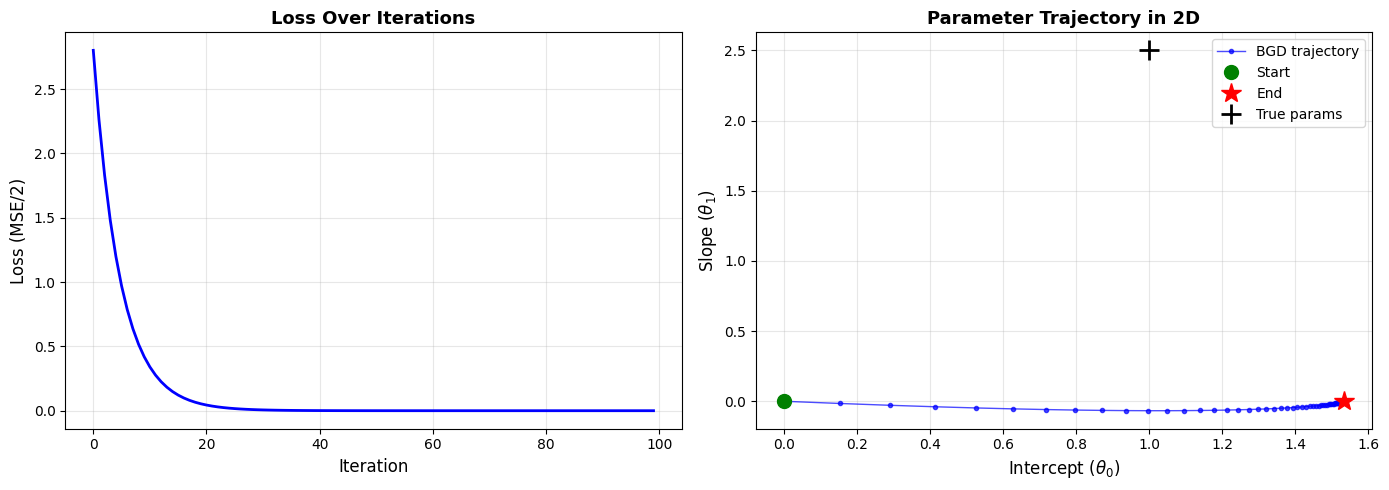

In [4]:
# Plot 1: Loss over iterations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(loss_history, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Loss (MSE/2)', fontsize=12)
axes[0].set_title('Loss Over Iterations', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Parameter trajectory
intercepts = [th[0, 0] for th in theta_history]
slopes = [th[1, 0] for th in theta_history]

axes[1].plot(intercepts, slopes, 'b.-', linewidth=1, markersize=6, label='BGD trajectory', alpha=0.7)
axes[1].plot(intercepts[0], slopes[0], 'go', markersize=10, label='Start')
axes[1].plot(intercepts[-1], slopes[-1], 'r*', markersize=15, label='End')
axes[1].plot(true_intercept, true_slope, 'k+', markersize=15, markeredgewidth=2, label='True params')
axes[1].set_xlabel('Intercept ($\\theta_0$)', fontsize=12)
axes[1].set_ylabel('Slope ($\\theta_1$)', fontsize=12)
axes[1].set_title('Parameter Trajectory in 2D', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Regression Results

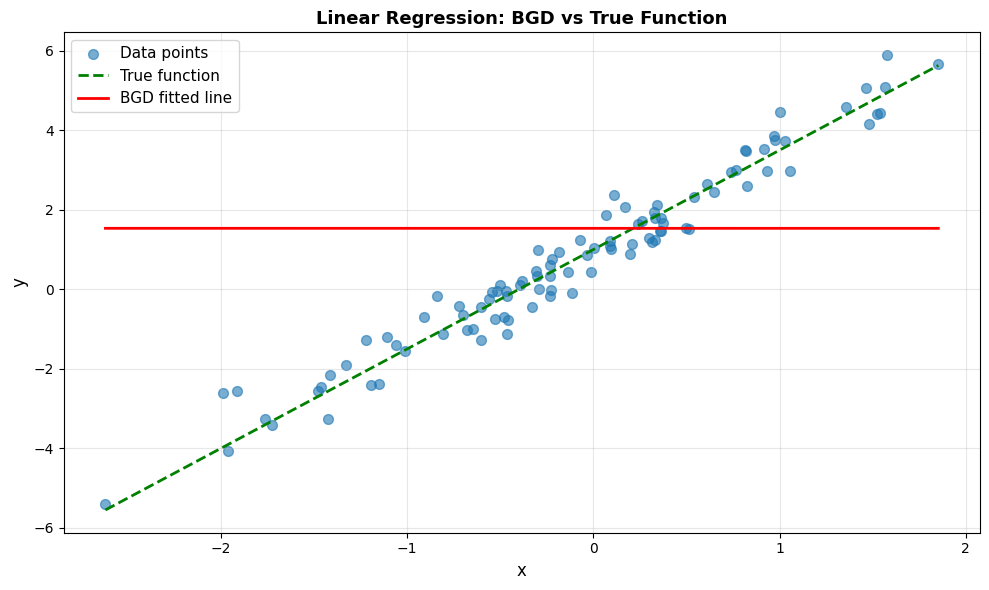

In [5]:
# Plot data and fitted line
plt.figure(figsize=(10, 6))

# Scatter plot of data
plt.scatter(X, y, alpha=0.6, s=50, label='Data points')

# True regression line
x_line = np.linspace(X.min(), X.max(), 100)
y_true_line = true_intercept + true_slope * x_line
plt.plot(x_line, y_true_line, 'g--', linewidth=2, label='True function')

# BGD fitted line
y_bgd_line = theta_final[0, 0] + theta_final[1, 0] * x_line
plt.plot(x_line, y_bgd_line, 'r-', linewidth=2, label='BGD fitted line')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Linear Regression: BGD vs True Function', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Effect of Learning Rate

The learning rate $\alpha$ is a critical hyperparameter that controls step size:

$$\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla J(\theta^{(t)})$$

- **Too small $\alpha$**: Slow convergence, many iterations needed
- **Too large $\alpha$**: May overshoot, diverge, or oscillate
- **Good $\alpha$**: Fast, stable convergence

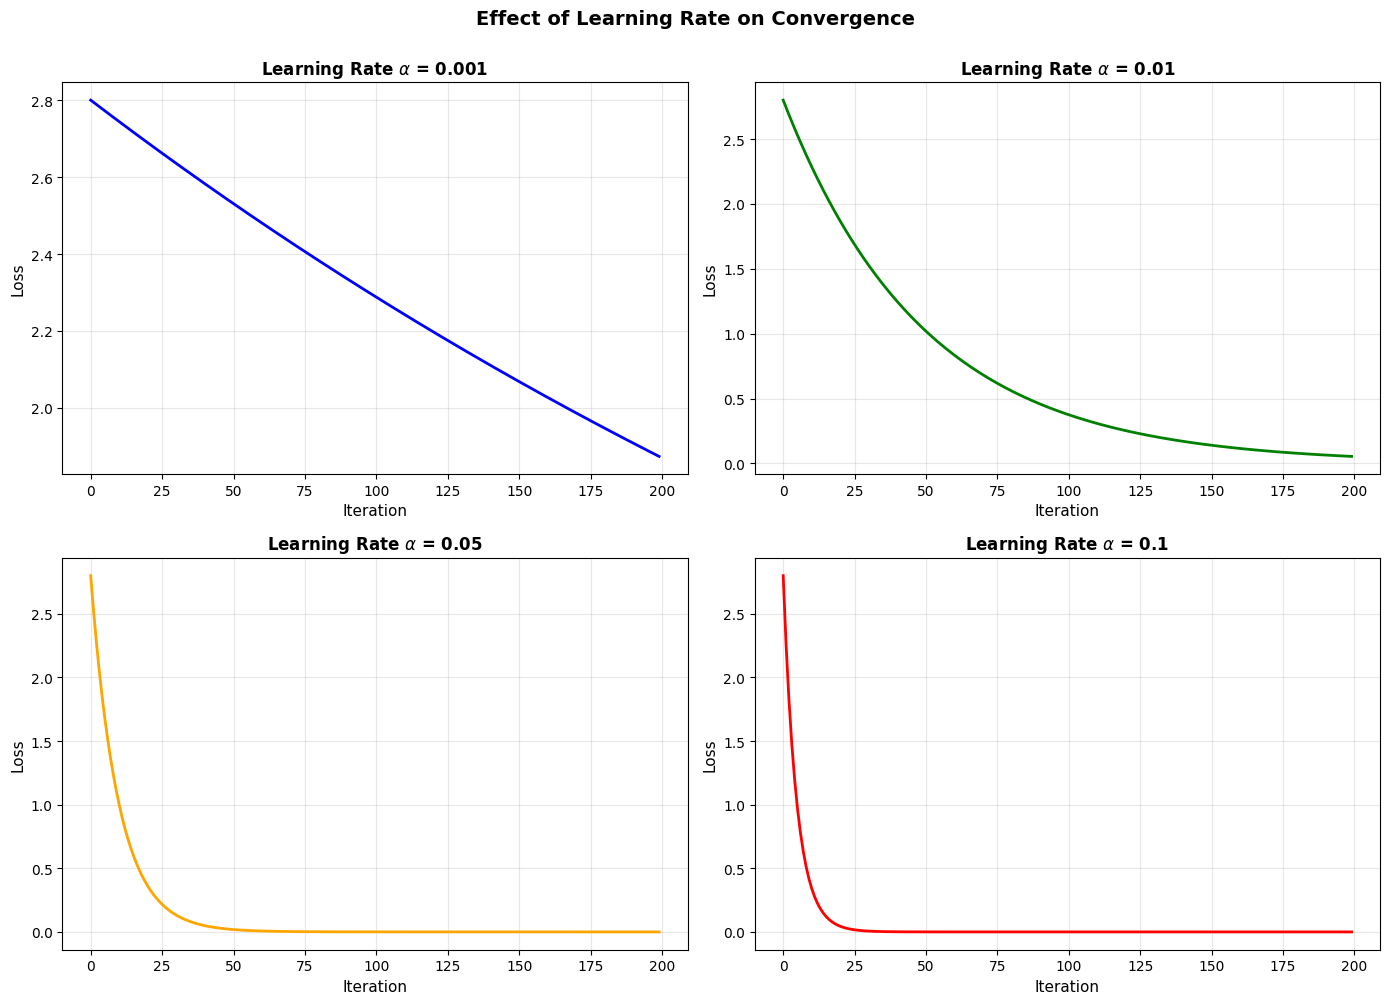

In [6]:
# Compare different learning rates
learning_rates = [0.001, 0.01, 0.05, 0.1]
colors = ['blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (lr, color) in enumerate(zip(learning_rates, colors)):
    _, loss_hist, _ = batch_gradient_descent(
        X_with_bias, y, learning_rate=lr, n_iterations=200
    )
    
    axes[idx].plot(loss_hist, color=color, linewidth=2)
    axes[idx].set_xlabel('Iteration', fontsize=11)
    axes[idx].set_ylabel('Loss', fontsize=11)
    axes[idx].set_title(f'Learning Rate $\\alpha$ = {lr}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Effect of Learning Rate on Convergence', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. Convergence Criteria

### 6.1 When to Stop

We need a criterion to determine when to stop optimization. Common choices:

**1. Gradient Magnitude**
$$\|\nabla J(\theta)\| < \epsilon_g$$
Stop when gradient is nearly zero (critical point).

**2. Loss Change**
$$|J(\theta^{(t)}) - J(\theta^{(t-1)})| < \epsilon_j$$
Stop when loss stops decreasing significantly.

**3. Fixed Iterations**
Stop after a fixed number of iterations (simplest).

**4. Validation-Based**
Stop when validation loss stops improving (early stopping).

In [7]:
def batch_gradient_descent_with_criteria(X, y, learning_rate=0.01, max_iterations=1000, 
                                         gradient_threshold=1e-6, loss_threshold=1e-6):
    """BGD with convergence criteria.
    
    Args:
        X: n x p design matrix
        y: n x 1 target vector
        learning_rate: Step size
        max_iterations: Maximum iterations
        gradient_threshold: Stop if ||gradient|| < threshold
        loss_threshold: Stop if |loss_change| < threshold
    
    Returns:
        theta: Optimized parameters
        loss_history: Loss at each iteration
        n_iterations: Actual number of iterations
        stop_reason: Why optimization stopped
    """
    n_features = X.shape[1]
    theta = np.zeros((n_features, 1))
    
    loss_history = []
    prev_loss = float('inf')
    
    for iteration in range(max_iterations):
        # Compute loss and gradient
        y_pred = X @ theta
        loss = mse_loss(y, y_pred)
        loss_history.append(loss)
        
        grad = gradient_mse(X, y, theta)
        grad_norm = np.linalg.norm(grad)
        
        # Check convergence criteria
        if grad_norm < gradient_threshold:
            return theta, loss_history, iteration + 1, "Gradient near zero"
        
        if abs(prev_loss - loss) < loss_threshold:
            return theta, loss_history, iteration + 1, "Loss change too small"
        
        # Update parameters
        theta = theta - learning_rate * grad
        prev_loss = loss
    
    return theta, loss_history, max_iterations, "Max iterations reached"

# Test with different thresholds
theta_opt, loss_hist, n_iters, reason = batch_gradient_descent_with_criteria(
    X_with_bias, y, learning_rate=0.1, max_iterations=1000,
    gradient_threshold=1e-6, loss_threshold=1e-8
)

print(f"Stopped after {n_iters} iterations")
print(f"Reason: {reason}")
print(f"Final loss: {loss_hist[-1]:.8f}")
print(f"Fitted parameters: intercept={theta_opt[0, 0]:.6f}, slope={theta_opt[1, 0]:.6f}")

Stopped after 99 iterations
Reason: Loss change too small
Final loss: 0.00000005
Fitted parameters: intercept=1.533978, slope=-0.000198


## 7. Batch Size and Data Complexity

### 7.1 Computational Complexity

In each iteration, BGD must:
1. Make predictions for all $n$ samples: $O(np)$ operations (matrix multiplication)
2. Compute gradients for all $n$ samples: $O(np)$ operations

**Total per iteration: $O(np)$**

For $T$ iterations:
$$\text{Total complexity} = O(Tnp)$$

where:
- $T$: Number of iterations needed for convergence
- $n$: Number of samples (dataset size)
- $p$: Number of features (parameter dimension)

### 7.2 Comparison with Other Methods

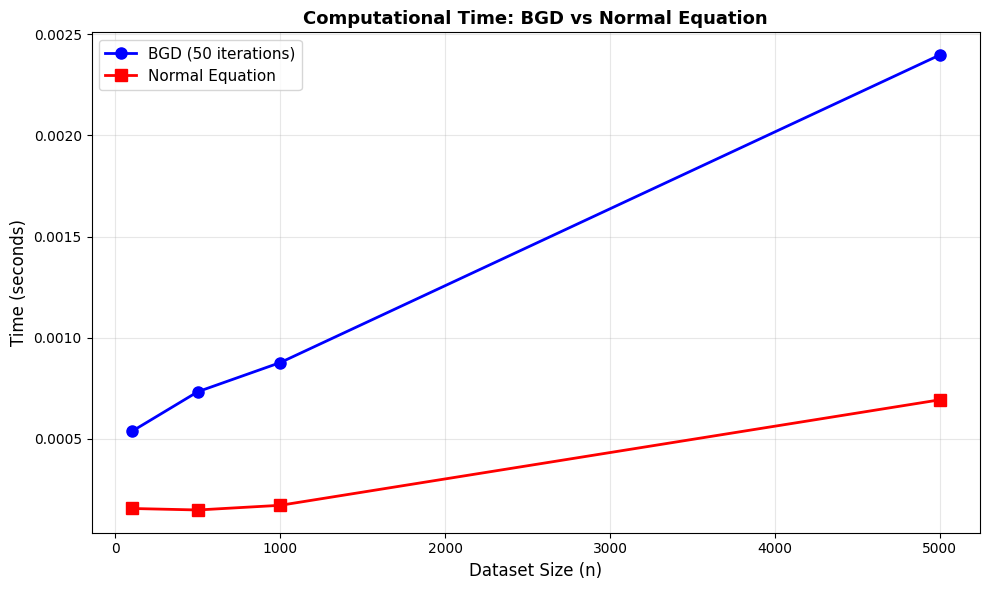

Timing Results:
Dataset Size    BGD (ms)        Normal Eq (ms) 
100             0.5372          0.1557         
500             0.7331          0.1483         
1000            0.8771          0.1714         
5000            2.3975          0.6928         


In [8]:
# Timing comparison: BGD vs Normal Equation (closed-form)
import time

# Test on different dataset sizes
dataset_sizes = [100, 500, 1000, 5000]
bgd_times = []
normal_eq_times = []

for n in dataset_sizes:
    # Generate data
    X_test = np.random.randn(n, 10)
    X_test_bias = np.hstack([np.ones((n, 1)), X_test])
    y_test = X_test @ np.random.randn(10, 1) + np.random.randn(n, 1) * 0.1
    
    # Time BGD (50 iterations)
    start = time.time()
    _, _, _ = batch_gradient_descent(X_test_bias, y_test, learning_rate=0.01, n_iterations=50)
    bgd_times.append(time.time() - start)
    
    # Time Normal Equation
    start = time.time()
    theta_normal = np.linalg.inv(X_test_bias.T @ X_test_bias) @ X_test_bias.T @ y_test
    normal_eq_times.append(time.time() - start)

# Plot timing comparison
plt.figure(figsize=(10, 6))
plt.plot(dataset_sizes, bgd_times, 'bo-', linewidth=2, markersize=8, label='BGD (50 iterations)')
plt.plot(dataset_sizes, normal_eq_times, 'rs-', linewidth=2, markersize=8, label='Normal Equation')
plt.xlabel('Dataset Size (n)', fontsize=12)
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('Computational Time: BGD vs Normal Equation', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Timing Results:")
print(f"{'Dataset Size':<15} {'BGD (ms)':<15} {'Normal Eq (ms)':<15}")
for n, bgd, ne in zip(dataset_sizes, bgd_times, normal_eq_times):
    print(f"{n:<15} {bgd*1000:<15.4f} {ne*1000:<15.4f}")

## 8. Advantages and Disadvantages

### 8.1 Summary Table

| Aspect | Details |
|--------|----------|
| **What** | Updates parameters using gradient computed on entire dataset |
| **Update Rule** | $\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla J(\theta^{(t)})$ |
| **Gradient Computation** | $\nabla J(\theta) = \frac{1}{n}\sum_{i=1}^{n} \nabla \ell_i(\theta)$ (averaged over all $n$ samples) |
| **Stability** | High (uses all data, low-variance gradient) |
| **Convergence** | Smooth, guaranteed for convex functions |
| **Time per Iteration** | $O(np)$ - depends on dataset size |
| **Memory** | $O(np)$ - need to store entire batch |
| **Parallelization** | Easy (compute gradients for samples in parallel) |
| **Local Minima** | Can get stuck for non-convex functions |

### 8.2 Pros and Cons

**Advantages:**
- Stable, reliable convergence
- Accurate gradient estimates (low variance)
- Smooth optimization trajectory
- Parallelizable
- Guaranteed global minimum for convex problems

**Disadvantages:**
- Slow for large datasets (O(n) per iteration)
- Memory intensive
- Cannot easily adapt to changing data
- Can get stuck in local minima for non-convex problems

## 9. Variants and Extensions

### 9.1 Gradient Descent Variants

**Batch Gradient Descent (BGD)**
- Uses all $n$ samples per iteration
- Stable but slow

**Stochastic Gradient Descent (SGD)**
- Uses 1 sample per iteration
- Fast but noisy

**Mini-batch Gradient Descent**
- Uses $k$ samples per iteration ($1 < k < n$)
- Balance between stability and speed

### 9.2 Advanced Optimization Algorithms

**Momentum**
$$v^{(t+1)} = \beta v^{(t)} + (1-\beta)\nabla J(\theta^{(t)})$$
$$\theta^{(t+1)} = \theta^{(t)} - \alpha v^{(t+1)}$$
Accumulates gradient information over iterations (like momentum in physics).

**Adam (Adaptive Moment Estimation)**
Uses adaptive learning rates based on first and second moments of gradients.

**RMSprop**
Adapts learning rate based on magnitude of recent gradients.

## 11. Library Functions for Batch Gradient Descent

### 11.1 Scikit-Learn

Scikit-learn provides convenient implementations of gradient descent-based optimizers through the `SGDRegressor` and `SGDClassifier` classes. These use stochastic/mini-batch gradient descent internally but can be configured for batch mode.

| Function | Purpose |
|----------|----------|
| `SGDRegressor(loss='squared_error', penalty=None)` | Linear regression with gradient descent (SGD/mini-batch) |
| `SGDClassifier(loss='log_loss')` | Classification with gradient descent |
| `LinearRegression()` | Normal equation solver (closed-form, no gradient descent) |
| `Ridge(alpha=1.0)` | L2 regularized regression |
| `Lasso(alpha=1.0)` | L1 regularized regression |

**Example:**
```python
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler

# Gradient descent with scikit-learn
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

sgd = SGDRegressor(
    loss='squared_error',
    max_iter=1000,
    learning_rate='constant',
    eta0=0.01,  # learning rate
    random_state=42
)
sgd.fit(X_scaled, y_train)
y_pred = sgd.predict(scaler.transform(X_test))

# Or use closed-form solution (no gradient descent)
lr = LinearRegression()
lr.fit(X_train, y_train)
```

### 11.2 PyTorch

PyTorch is excellent for building custom models with automatic differentiation. The optimizer classes handle the parameter updates.

| Function | Purpose |
|----------|----------|
| `torch.optim.SGD(params, lr)` | Stochastic Gradient Descent optimizer |
| `torch.optim.Adam(params, lr)` | Adaptive Moment Estimation optimizer |
| `torch.nn.MSELoss()` | Mean squared error loss |
| `model.zero_grad()` | Clear gradients before backpropagation |
| `.backward()` | Compute gradients via backpropagation |

**Example:**
```python
import torch
import torch.nn as nn
from torch.optim import SGD, Adam

# Define model
model = nn.Linear(n_features, 1)

# Define optimizer and loss
optimizer = SGD(model.parameters(), lr=0.01)
# optimizer = Adam(model.parameters(), lr=0.001)  # Alternative
loss_fn = nn.MSELoss()

# Training loop
n_epochs = 100
for epoch in range(n_epochs):
    # Forward pass
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    
    # Backward pass (compute gradients)
    optimizer.zero_grad()  # Clear old gradients
    loss.backward()        # Compute new gradients
    
    # Update parameters
    optimizer.step()       # Take one optimization step
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}')
```

### 11.3 TensorFlow/Keras

TensorFlow provides high-level APIs through Keras for easy model building and training.

| Function | Purpose |
|----------|----------|
| `tf.keras.optimizers.SGD(learning_rate)` | SGD optimizer |
| `tf.keras.optimizers.Adam(learning_rate)` | Adam optimizer |
| `tf.keras.layers.Dense()` | Fully connected (linear) layer |
| `model.compile()` | Configure optimizer and loss |
| `model.fit()` | Training loop |

**Example:**
```python
import tensorflow as tf
from tensorflow import keras

# Define model
model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(n_features,))
])

# Compile with optimizer and loss
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='mse'
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=len(X_train),  # Use full batch for BGD
    verbose=1
)

# Make predictions
y_pred = model.predict(X_test)
```

### 11.4 SciPy

SciPy provides general-purpose optimization functions that can perform gradient-based optimization.

| Function | Purpose |
|----------|----------|
| `scipy.optimize.minimize(method='BFGS')` | General-purpose optimization with gradients |
| `scipy.optimize.least_squares()` | Non-linear least squares |

**Example:**
```python
from scipy.optimize import minimize
import numpy as np

# Define loss function
def loss_function(theta):
    y_pred = X @ theta.reshape(-1, 1)
    mse = np.mean((y - y_pred)**2) / 2
    return mse

# Define gradient function (optional but recommended)
def gradient_function(theta):
    y_pred = X @ theta.reshape(-1, 1)
    grad = (1 / len(X)) * (X.T @ (y_pred - y)).flatten()
    return grad

# Optimize
result = minimize(
    loss_function,
    x0=np.zeros(n_features),
    method='BFGS',  # Or 'L-BFGS-B', 'CG', etc.
    jac=gradient_function  # Provide gradient for efficiency
)

theta_optimal = result.x
print(f'Optimization success: {result.success}')
print(f'Final loss: {result.fun}')
```

### 11.5 JAX

JAX is a modern framework for automatic differentiation and high-performance computing.

| Function | Purpose |
|----------|----------|
| `jax.grad()` | Automatic differentiation (compute gradients) |
| `optax.sgd(learning_rate)` | SGD optimizer |
| `optax.adam(learning_rate)` | Adam optimizer |

**Example:**
```python
import jax
import jax.numpy as jnp
import optax

# Define loss function
def loss_fn(theta, X, y):
    y_pred = X @ theta
    return jnp.mean((y - y_pred)**2) / 2

# Create gradient function
grad_fn = jax.grad(loss_fn)

# Initialize optimizer
optimizer = optax.sgd(learning_rate=0.01)
theta = jnp.zeros(n_features)
opt_state = optimizer.init(theta)

# Training loop
n_epochs = 100
for epoch in range(n_epochs):
    # Compute gradients
    grads = grad_fn(theta, X, y)
    
    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    theta = optax.apply_updates(theta, updates)
    
    if (epoch + 1) % 10 == 0:
        loss = loss_fn(theta, X, y)
        print(f'Epoch {epoch+1}, Loss: {loss:.4f}')
```

### 11.6 Comparison Table

| Library | Best For | Ease of Use | Performance | Flexibility |
|---------|----------|------------|-------------|-------------|
| **Scikit-Learn** | Classical ML, quick prototyping | Very Easy | Good | Limited |
| **PyTorch** | Deep learning, research | Easy | Excellent | Excellent |
| **TensorFlow/Keras** | Production ML, deep learning | Easy-Medium | Excellent | Good |
| **SciPy** | General optimization problems | Medium | Good | Excellent |
| **JAX** | High-performance computing, research | Medium-Hard | Excellent | Excellent |
| **Custom NumPy** | Learning, understanding | Hard | Fair | Excellent |

### 11.7 Practical Recommendations

- **For learning**: Implement from scratch with NumPy (as we did in this notebook)
- **For batch gradient descent specifically**: Use `SGDRegressor` from scikit-learn with full batch size
- **For deep learning**: Use PyTorch or TensorFlow/Keras
- **For production models**: Use scikit-learn for classical ML or TensorFlow for deep learning
- **For regularized models**: Add `penalty='l2'` or `penalty='l1'` to scikit-learn, or use `Ridge`/`Lasso`
- **For modern optimization**: Use `Adam` optimizer instead of vanilla BGD (often converges faster)


## 10. Key Takeaways

1. **Core Idea**: Minimize loss by taking steps opposite to the gradient
2. **Update Rule**: $\theta^{(t+1)} = \theta^{(t)} - \alpha \nabla J(\theta^{(t)})$
3. **Batch**: Uses entire dataset for stable, accurate gradients
4. **Learning Rate**: Critical hyperparameter controlling step size
5. **Convergence**: Guaranteed for convex functions, smooth trajectory
6. **Trade-off**: Stability vs. speed (large datasets make it slow)
7. **Foundation**: BGD is the basis for understanding SGD, mini-batch, and advanced optimizers

## 11. Library Functions for Batch Gradient Descent

### 11.1 Scikit-Learn

Scikit-learn provides convenient implementations of gradient descent-based optimizers through the `SGDRegressor` and `SGDClassifier` classes. These use stochastic/mini-batch gradient descent internally but can be configured for batch mode.

| Function | Purpose |
|----------|---------|
| `SGDRegressor(loss='squared_error', penalty=None)` | Linear regression with gradient descent (SGD/mini-batch) |
| `SGDClassifier(loss='log_loss')` | Classification with gradient descent |
| `LinearRegression()` | Normal equation solver (closed-form, no gradient descent) |
| `Ridge(alpha=1.0)` | L2 regularized regression |
| `Lasso(alpha=1.0)` | L1 regularized regression |

**Example:**
```python
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler

# Gradient descent with scikit-learn
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

sgd = SGDRegressor(
    loss='squared_error',
    max_iter=1000,
    learning_rate='constant',
    eta0=0.01,  # learning rate
    random_state=42
)
sgd.fit(X_scaled, y_train)
y_pred = sgd.predict(scaler.transform(X_test))

# Or use closed-form solution (no gradient descent)
lr = LinearRegression()
lr.fit(X_train, y_train)
```

### 11.2 PyTorch

PyTorch is excellent for building custom models with automatic differentiation. The optimizer classes handle the parameter updates.

| Function | Purpose |
|----------|---------|
| `torch.optim.SGD(params, lr)` | Stochastic Gradient Descent optimizer |
| `torch.optim.Adam(params, lr)` | Adaptive Moment Estimation optimizer |
| `torch.nn.MSELoss()` | Mean squared error loss |
| `model.zero_grad()` | Clear gradients before backpropagation |
| `.backward()` | Compute gradients via backpropagation |

**Example:**
```python
import torch
import torch.nn as nn
from torch.optim import SGD, Adam

# Define model
model = nn.Linear(n_features, 1)

# Define optimizer and loss
optimizer = SGD(model.parameters(), lr=0.01)
# optimizer = Adam(model.parameters(), lr=0.001)  # Alternative
loss_fn = nn.MSELoss()

# Training loop
n_epochs = 100
for epoch in range(n_epochs):
    # Forward pass
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    
    # Backward pass (compute gradients)
    optimizer.zero_grad()  # Clear old gradients
    loss.backward()        # Compute new gradients
    
    # Update parameters
    optimizer.step()       # Take one optimization step
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}')
```

### 11.3 TensorFlow/Keras

TensorFlow provides high-level APIs through Keras for easy model building and training.

| Function | Purpose |
|----------|---------|
| `tf.keras.optimizers.SGD(learning_rate)` | SGD optimizer |
| `tf.keras.optimizers.Adam(learning_rate)` | Adam optimizer |
| `tf.keras.layers.Dense()` | Fully connected (linear) layer |
| `model.compile()` | Configure optimizer and loss |
| `model.fit()` | Training loop |

**Example:**
```python
import tensorflow as tf
from tensorflow import keras

# Define model
model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(n_features,))
])

# Compile with optimizer and loss
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='mse'
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=len(X_train),  # Use full batch for BGD
    verbose=1
)

# Make predictions
y_pred = model.predict(X_test)
```

### 11.4 SciPy

SciPy provides general-purpose optimization functions that can perform gradient-based optimization.

| Function | Purpose |
|----------|---------|
| `scipy.optimize.minimize(method='BFGS')` | General-purpose optimization with gradients |
| `scipy.optimize.least_squares()` | Non-linear least squares |

**Example:**
```python
from scipy.optimize import minimize
import numpy as np

# Define loss function
def loss_function(theta):
    y_pred = X @ theta.reshape(-1, 1)
    mse = np.mean((y - y_pred)**2) / 2
    return mse

# Define gradient function (optional but recommended)
def gradient_function(theta):
    y_pred = X @ theta.reshape(-1, 1)
    grad = (1 / len(X)) * (X.T @ (y_pred - y)).flatten()
    return grad

# Optimize
result = minimize(
    loss_function,
    x0=np.zeros(n_features),
    method='BFGS',  # Or 'L-BFGS-B', 'CG', etc.
    jac=gradient_function  # Provide gradient for efficiency
)

theta_optimal = result.x
print(f'Optimization success: {result.success}')
print(f'Final loss: {result.fun}')
```

### 11.5 JAX

JAX is a modern framework for automatic differentiation and high-performance computing.

| Function | Purpose |
|----------|---------|
| `jax.grad()` | Automatic differentiation (compute gradients) |
| `optax.sgd(learning_rate)` | SGD optimizer |
| `optax.adam(learning_rate)` | Adam optimizer |

**Example:**
```python
import jax
import jax.numpy as jnp
import optax

# Define loss function
def loss_fn(theta, X, y):
    y_pred = X @ theta
    return jnp.mean((y - y_pred)**2) / 2

# Create gradient function
grad_fn = jax.grad(loss_fn)

# Initialize optimizer
optimizer = optax.sgd(learning_rate=0.01)
theta = jnp.zeros(n_features)
opt_state = optimizer.init(theta)

# Training loop
n_epochs = 100
for epoch in range(n_epochs):
    # Compute gradients
    grads = grad_fn(theta, X, y)
    
    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    theta = optax.apply_updates(theta, updates)
    
    if (epoch + 1) % 10 == 0:
        loss = loss_fn(theta, X, y)
        print(f'Epoch {epoch+1}, Loss: {loss:.4f}')
```

### 11.6 Comparison Table

| Library | Best For | Ease of Use | Performance | Flexibility |
|---------|----------|------------|-------------|------------|
| **Scikit-Learn** | Classical ML, quick prototyping | Very Easy | Good | Limited |
| **PyTorch** | Deep learning, research | Easy | Excellent | Excellent |
| **TensorFlow/Keras** | Production ML, deep learning | Easy-Medium | Excellent | Good |
| **SciPy** | General optimization problems | Medium | Good | Excellent |
| **JAX** | High-performance computing, research | Medium-Hard | Excellent | Excellent |
| **Custom NumPy** | Learning, understanding | Hard | Fair | Excellent |

### 11.7 Practical Recommendations

- **For learning**: Implement from scratch with NumPy (as we did in this notebook)
- **For batch gradient descent specifically**: Use `SGDRegressor` from scikit-learn with full batch size
- **For deep learning**: Use PyTorch or TensorFlow/Keras
- **For production models**: Use scikit-learn for classical ML or TensorFlow for deep learning
- **For regularized models**: Add `penalty='l2'` or `penalty='l1'` to scikit-learn, or use `Ridge`/`Lasso`
- **For modern optimization**: Use `Adam` optimizer instead of vanilla BGD (often converges faster)

## References

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
- Boyd, S., & Vandenberghe, L. (2004). Convex Optimization. Cambridge University Press.
- Ruder, S. (2016). An overview of gradient descent optimization algorithms. arXiv:1609.04747.